In [ ]:
# 행렬을 이용한 내적 연산 --> 벡터의 내적연산
# w1*x1 + w2*x2 w3*x3 + b
# step function : 0보다 크면 1, 0보다 작으면 0
# 활성화 함수 : step function, sigmoid function, relu function
# 계단함수가 필요한 이유 : 비선형적인 행동을 해야지만 구역을 나누는 기준선(Decison Boundary)을 만들 수 있다
# 활성화 함수가 없으면 아무리 층을 깊게 쌓아도 결국 선형함수 밖에 만들 수 없다 (형태: y = wx + b)

In [2]:
import torch

# step function
def step_func(x):
    return (x >= 0).float()

In [3]:
# y = 0.5*x1 + 0.5*x2 - 0.7
# 0
X = torch.tensor([
    [0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]
])
w = torch.tensor([ [0.5], [0.5] ])
b = -0.7

In [4]:
# 배치 행렬곱을 지원 (브로드캐스팅 포함)
# (batch, n, m) @ (batch, n, m)
z = torch.matmul(X, w) + b
# 계단함수 통과
output_ = step_func(z)
for x_val, out_val in zip(X, output_):
    print(f'입력 {x_val}, 출력 {out_val}')

입력 tensor([0., 0.]), 출력 tensor([0.])
입력 tensor([0., 1.]), 출력 tensor([0.])
입력 tensor([1., 0.]), 출력 tensor([0.])
입력 tensor([1., 1.]), 출력 tensor([1.])


In [6]:
# xor : 입력이 서로 다를때만 1을 출력
# 임의로 가중치를 xor
w_xor = torch.tensor([ [1.0], [1.0] ])
b_xor = -0.5

z = torch.matmul(X, w_xor) + b_xor
output_xor = step_func(z)

for x_val, out_val in zip(X, output_xor):
    corrent_target = int(x_val[0] != x_val[1])
    print(f'입력 {x_val}, 출력 {out_val}, 정답 {corrent_target}')

입력 tensor([0., 0.]), 출력 tensor([0.]), 정답 0
입력 tensor([0., 1.]), 출력 tensor([1.]), 정답 1
입력 tensor([1., 0.]), 출력 tensor([1.]), 정답 1
입력 tensor([1., 1.]), 출력 tensor([1.]), 정답 0


In [ ]:
# 다층 퍼셉트론 : 은닉층(hidden layer)
# 활성화 함수 : 시그모이드나 ReLU같은 파생 활성화 함수

# X = [1.0, 0.0]
# z1 = w11 * x1 + w21 * x2 + b1
# z2 = w12 * x1 + w22 * x2 + b2
# ....
# z = x * w + b

# z의 값에 활성화 함수 시그모이드 씌우면 -값이 아무리 크기가 작아도 0~1 사이로 압축
# 직선이었던 데이터 공간이 곡선으로 휘어짐

# X
# z = xw1 + b1
# h = sigmoid(z)
# z2 = hw2 + b2
# y = sigmoid(z2)
# 최종예측 y

# x = [1.0, 0.0]
# w1 = [
#     20 -20
#     20 -20
# ]
# b = [-10, 30]
# w2 = [
#     20
#     20
# ]
# b2 = [-30]

# 은닉층 선형결합
# z = [1.0, 0.0] @ [20 -20      + [-10, 30]  =  [10, 10]
#                   20 -20]
# 시그모이드 [0.9999, 0.9999]
# 출력층 [0.9999, 0.9999] @ [20
#                           20 + (-30)  = 39.998 -30  = 9.998
#                           ]
# 출력 활성화 시그모이드(9.998) = 0.99999  ->  판정 1

In [1]:
# 활성화 함수의 필요성 -> 선형붕괴 (활성화 함수 없이 층을 쌓으면 의미가 없다)
# 1층 h = w1 * X + b1
# 2층 y = w2 * h + b2 = w2(w1 * X b1) + b2
# w2*w1*X + w2*b1 + b2
# w' = w2w1  b' = w2b1 + b2
# y = w'x + b'

# 활성화 함수는 공간 변형 도구
# 계단함수는 판단은 가능하지만 학습은 불가능 (미분 불가능, 기울기 0이라 기울기 알 수 없음)

In [7]:
import torch
torch.sigmoid(torch.tensor(0))

tensor(0.5000)

시그모이드 식 : 
$
\sigma(x) = \frac{1}{1 + e^{-x}}
$

시그모이드 미분 식 : 
$
\sigma'(x) = \sigma(x)\left(1 - \sigma(x)\right)
$

In [3]:
#   X      시그모이드   시그모이드 미분
#   0       0.5          0.25        가장 활발하게 학습
# +- 2    0.88 / 0.12    0.10        학습속도 둔화 
# +- 5    0.99 / 0.01    0.0067      거의 학습이 안됨
# +- 10      1 / 0        0          완전 정지 (뉴런 사망)

In [8]:
# torch 자동미분 기능
import torch
x = torch.tensor([0.0], requires_grad=True)  # requires_grad=True 미분세팅
y = torch.sigmoid(x)
y.backward()     # backward : 출력 y를 기준으로, 입력 x에 대한 "기울기(미분값)"를 계산하는 함수
print(x.grad)    # grad : 미분 결과(기울기)를 저장하는 변수

tensor([0.2500])


In [9]:
# ReLU
# f(x) = z = max(0, x)
import numpy as np
x = np.array([-5, 0, 2, 6, -5])
np.maximum(0, x)

array([0, 0, 2, 6, 0])

In [7]:
# ReLU는 미분을 하면 양수 구간은 항상 1
# 1 * 1 * 1 * 1 == 1 기울기가 죽지 않고 끝까지 전달
# 입력이 음수면 기울기가 0 출력 비활성화 -> 계산중에 불필요한 뉴런 제거하는 효과
# 시그모이드 보다 6배 이상 빠르고 안정적으로 학습 가능

In [8]:
# 케라스
# %pip install tensorflow

In [10]:
import tensorflow as tf

fasion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [12]:
(x_train_full, y_train_full), (x_test, y_test) = fasion_mnist
x_train_full.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [13]:
x_train, y_train = x_train_full[:-5000], y_train_full[:-5000]
x_valid, y_valid = x_train_full[-5000:], y_train_full[-5000:]
x_train.shape, x_valid.shape

((55000, 28, 28), (5000, 28, 28))

In [14]:
x_train, x_valid, x_test = x_train / 255. , x_valid / 255. , x_test / 255.

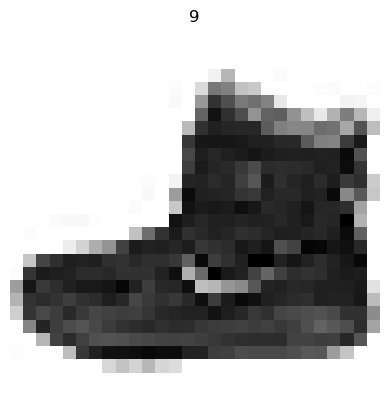

In [15]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='binary')
plt.axis('off')
plt.title(y_train[0])
plt.show()

In [16]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [17]:
# 다중분류 (multi class, 단일 정답)
# 마지막 출력층에서 soft max  ->  모든 출력의 합이 1, 확률 분포 형태
# 각 클래스 별로 확률 값
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation='relu'))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))   # 마지막 확률 분포

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [20]:
# 컴파일 
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [21]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7653 - loss: 0.7180 - val_accuracy: 0.8294 - val_loss: 0.5034
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8307 - loss: 0.4863 - val_accuracy: 0.8378 - val_loss: 0.4538
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8451 - loss: 0.4432 - val_accuracy: 0.8478 - val_loss: 0.4299
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8540 - loss: 0.4158 - val_accuracy: 0.8568 - val_loss: 0.4120
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8607 - loss: 0.3951 - val_accuracy: 0.8582 - val_loss: 0.4000
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8662 - loss: 0.3788 - val_accuracy: 0.8576 - val_loss: 0.3901
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8712 - loss: 0.3651 - val_accuracy: 0.8604 - val_loss: 0.3819
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8749 - loss: 0.3531 - 

In [22]:
predict_ = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step


In [23]:
predict_

array([[8.6646260e-06, 4.1183705e-07, 2.8014867e-05, ..., 1.6103657e-02,
        2.3758422e-04, 8.7332046e-01],
       [4.4733588e-05, 1.3941626e-08, 9.9941242e-01, ..., 5.7572887e-12,
        2.1471893e-08, 4.3948075e-13],
       [6.7551673e-06, 9.9999249e-01, 3.1728753e-08, ..., 4.5938815e-11,
        1.5598756e-09, 1.4494170e-10],
       ...,
       [1.7547733e-03, 1.0845298e-06, 1.3629667e-03, ..., 1.0889790e-06,
        9.9627101e-01, 1.2531868e-07],
       [4.3951486e-06, 9.9988508e-01, 5.7885932e-06, ..., 7.0284727e-08,
        7.5578747e-08, 6.1589969e-07],
       [4.4624908e-06, 6.7623432e-07, 2.1100366e-05, ..., 1.3736216e-03,
        1.3903814e-04, 1.4820923e-05]], dtype=float32)

In [25]:
sum(np.argmax(predict_, axis=1) == y_test) / len(y_test)

0.8753

In [26]:
from sklearn.metrics import classification_report
y_pred = np.argmax(predict_, axis=1)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.76      0.83      0.80      1000
           3       0.83      0.93      0.87      1000
           4       0.79      0.81      0.80      1000
           5       0.90      0.98      0.94      1000
           6       0.78      0.60      0.68      1000
           7       0.94      0.91      0.93      1000
           8       0.95      0.97      0.96      1000
           9       0.98      0.93      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



In [43]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

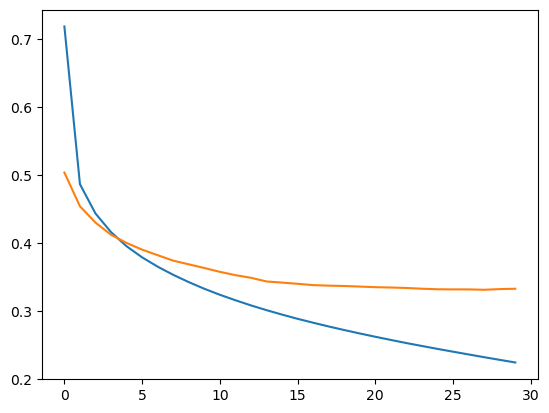

In [ ]:
# 시각화
# x 축은 range(30)
# y 축은 loss, val_loss
# plt.plot

import matplotlib.pyplot as plt

plt.plot(range(30), history.history['loss'], label='train_loss')
plt.plot(range(30), history.history['val_loss'], label='val_loss')
plt.show()

In [32]:
import torch.nn as nn

torch.manual_seed(42)

class SigmoidNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4,8)
        self.layer2 = nn.Linear(8,8)
        self.layer3 = nn.Linear(8,8)
        self.layer4 = nn.Linear(8,8)
        self.layer5 = nn.Linear(8,1)

    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        x = torch.sigmoid(self.layer3(x))
        x = torch.sigmoid(self.layer4(x))
        x = self.layer5(x)
        return x
    
sigmoid_net = SigmoidNet()
sigmoid_net

SigmoidNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=8, bias=True)
  (layer4): Linear(in_features=8, out_features=8, bias=True)
  (layer5): Linear(in_features=8, out_features=1, bias=True)
)

In [36]:
x_input = torch.randn(1,4)
y_target = torch.tensor([[1.0]])
output = sigmoid_net(x_input)
loss = (y_target - output)**2
loss.backward()

In [40]:
for name, param in sigmoid_net.named_parameters():
    grade_magnitude = param.grad.abs().mean().item()   # item() : 텐서에서 벗어나게 해줌 
    status = '소실' if grade_magnitude < 0.001 else '보통' if grade_magnitude > 0.01 else '양호'
    print(name, grade_magnitude, status)

layer1.weight 0.0001970449520740658 소실
layer1.bias 0.0002025977155426517 소실
layer2.weight 0.0005189195508137345 소실
layer2.bias 0.0009850841015577316 소실
layer3.weight 0.0033919087145477533 양호
layer3.bias 0.007354467175900936 양호
layer4.weight 0.03504737839102745 보통
layer4.bias 0.07489149272441864 보통
layer5.weight 0.6412580013275146 보통
layer5.bias 1.4335606098175049 보통


In [43]:
import torch.nn as nn

torch.manual_seed(42)

class ReLUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4,8)
        self.layer2 = nn.Linear(8,8)
        self.layer3 = nn.Linear(8,8)
        self.layer4 = nn.Linear(8,8)
        self.layer5 = nn.Linear(8,1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.relu(self.layer3(x))
        x = torch.relu(self.layer4(x))
        x = self.layer5(x)
        return x
    
relu_net = ReLUNet()

x_input = torch.randn(1,4)
y_target = torch.tensor([[1.0]])
output = relu_net(x_input)
loss = (y_target - output)**2
loss.backward()

for name, param in relu_net.named_parameters():
    grade_magnitude = param.grad.abs().mean().item()   # item() : 텐서에서 벗어나게 해줌 
    status = '소실' if grade_magnitude < 0.001 else '보통' if grade_magnitude > 0.01 else '양호'
    print(name, grade_magnitude, status)

layer1.weight 0.0035197765100747347 양호
layer1.bias 0.004575605504214764 양호
layer2.weight 0.0038204193115234375 양호
layer2.bias 0.009269200265407562 양호
layer3.weight 0.0021929943468421698 양호
layer3.bias 0.025592617690563202 보통
layer4.weight 0.005429559387266636 양호
layer4.bias 0.05685833841562271 보통
layer5.weight 0.05177631601691246 보통
layer5.bias 1.8479589223861694 보통


In [45]:
import torch.nn as nn

torch.manual_seed(42)

class ReLUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4,8)
        self.layer2 = nn.Linear(8,8)
        self.layer3 = nn.Linear(8,8)
        self.layer4 = nn.Linear(8,8)
        self.layer5 = nn.Linear(8,1)
        self.leakyRelu = nn.LeakyReLU()

    def forward(self, x):
        x = self.leakyRelu(self.layer1(x))
        x = self.leakyRelu(self.layer2(x))
        x = self.leakyRelu(self.layer3(x))
        x = self.leakyRelu(self.layer4(x))
        x = self.layer5(x)
        return x
    
relu_net = ReLUNet()

x_input = torch.randn(1,4)
y_target = torch.tensor([[1.0]])
output = relu_net(x_input)
loss = (y_target - output)**2
loss.backward()

for name, param in relu_net.named_parameters():
    grade_magnitude = param.grad.abs().mean().item()   # item() : 텐서에서 벗어나게 해줌 
    status = '소실' if grade_magnitude < 0.001 else '보통' if grade_magnitude > 0.01 else '양호'
    print(name, grade_magnitude, status)

layer1.weight 0.003524485509842634 양호
layer1.bias 0.004581727087497711 양호
layer2.weight 0.003884008154273033 양호
layer2.bias 0.009393860585987568 양호
layer3.weight 0.0023075814824551344 양호
layer3.bias 0.02644430473446846 보통
layer4.weight 0.005813978612422943 양호
layer4.bias 0.06026383116841316 보통
layer5.weight 0.054165832698345184 보통
layer5.bias 1.8474719524383545 보통
